In [4]:
import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [5]:
# ── File paths ───────────────────────────────────────────────────────────────
CASES = {
    'single_case1':  {
        'csv': '../data/merged/single_case1_merged.csv',
        'gt':  '../data/raw/Single Case-1/Case-1/groundtruth/groundtruth.json',
    },
    'single_case2':  {
        'csv': '../data/merged/single_case2_merged.csv',
        'gt':  '../data/raw/Single Case-2/Case-2/groundtruth/groundtruth.json',
    },
    'complex_case1': {
        'csv': '../data/merged/complex_case1_merged.csv',
        'gt':  '../data/raw/Complex Case-1/Case-1/groundtruth/groundtruth.json',
    },
    'complex_case2': {
        'csv': '../data/merged/complex_case2_merged.csv',
        'gt':  '../data/raw/Complex Case-2/Case-2/groundtruth/groundtruth.json',
    },
}

METRIC_COLS = [
    'container_cpu_usage_seconds_total',
    'container_cpu_system_seconds_total',
    'container_cpu_user_seconds_total',
    'container_memory_usage_bytes',
    'container_memory_working_set_bytes',
    'container_memory_rss',
    'container_memory_cache',
]

In [6]:
# ── Step 1: Load data and groundtruth ────────────────────────────────────────
raw = {}
for name, paths in CASES.items():
    df = pd.read_csv(paths['csv'])
    with open(paths['gt']) as f:
        gt = json.load(f)
    raw[name] = {'df': df, 'gt': gt}
    print(f'Loaded {name}: {len(df):,} rows | {len(gt["timestamp"])} fault events')

Loaded single_case1: 74,223 rows | 3 fault events
Loaded single_case2: 45,738 rows | 2 fault events
Loaded complex_case1: 318,445 rows | 12 fault events
Loaded complex_case2: 94,932 rows | 23 fault events


In [7]:
# ── Step 2: Labeling function ────────────────────────────────────────────────
# Logic:
#   - groundtruth cmdb_id format:  "paymentservice-1"   (no prefix)
#   - merged CSV cmdb_id format:   "observe.paymentservice-1"
#   - A row is anomaly (1) if:
#       stripped_cmdb_id == gt_cmdb_id  AND
#       gt_timestamp <= row_timestamp < gt_timestamp + gt_duration
#   - failure_type column uses None (object dtype) so string labels
#     like 'cpu'/'memory' can be assigned without dtype conflicts

def apply_labels(df, gt):
    df = df.copy()

    # Strip 'observe.' prefix for matching
    df['short_id'] = df['cmdb_id'].str.replace('observe.', '', regex=False)

    df['label'] = 0
    # Use None (object dtype) instead of np.nan (float64) so string
    # fault-type values can be assigned without a dtype conflict
    df['failure_type'] = None

    for ts, cid, dur, ftype in zip(
        gt['timestamp'], gt['cmdb_id'], gt['duration'], gt['failure_type']
    ):
        in_window = (df['timestamp'] >= ts) & (df['timestamp'] < ts + dur)
        id_match  = df['short_id'] == cid
        mask      = in_window & id_match

        df.loc[mask, 'label']        = 1
        df.loc[mask, 'failure_type'] = ftype

    df.drop(columns=['short_id'], inplace=True)
    return df

In [8]:
# ── Step 3: Apply labels to all 4 cases ─────────────────────────────────────
labeled = {}
for name, data in raw.items():
    labeled[name] = apply_labels(data['df'], data['gt'])

print('Labeling done.')

Labeling done.


In [9]:
# ── Step 4: Label distribution per case ─────────────────────────────────────
for name, df in labeled.items():
    counts = df['label'].value_counts()
    pct    = (counts / len(df) * 100).round(1)
    print(f'\n{name}:')
    print(f'  Benign (0):  {counts.get(0, 0):>7,}  ({pct.get(0, 0)}%)')
    print(f'  Anomaly (1): {counts.get(1, 0):>7,}  ({pct.get(1, 0)}%)')

    if 1 in counts:
        ftypes = df[df['label'] == 1]['failure_type'].value_counts().to_dict()
        print(f'  Fault types: {ftypes}')


single_case1:
  Benign (0):   74,107  (99.8%)
  Anomaly (1):     116  (0.2%)
  Fault types: {'memory': 40, 'loss': 40, 'cpu': 36}

single_case2:
  Benign (0):   45,682  (99.9%)
  Anomaly (1):      56  (0.1%)
  Fault types: {'pod-failure': 56}

complex_case1:
  Benign (0):  317,203  (99.6%)
  Anomaly (1):   1,242  (0.4%)
  Fault types: {'delay': 378, 'pod-failure': 346, 'loss': 227, 'memory': 203, 'cpu': 88}

complex_case2:
  Benign (0):   94,120  (99.1%)
  Anomaly (1):     812  (0.9%)
  Fault types: {'loss': 360, 'memory': 240, 'cpu': 120, 'delay': 80, 'pod-failure': 12}


In [10]:
# ── Step 5: Verify labeling on a known fault ─────────────────────────────────
# single_case1 groundtruth: paymentservice-1, cpu fault at ts=1719256800, dur=540
df_sc1 = labeled['single_case1']
check = df_sc1[
    df_sc1['cmdb_id'].str.contains('paymentservice-1') &
    (df_sc1['timestamp'] >= 1719256800) &
    (df_sc1['timestamp'] < 1719256800 + 540)
][['timestamp', 'cmdb_id', 'container_cpu_usage_seconds_total', 'label', 'failure_type']]

print(f'Rows in paymentservice-1 cpu fault window: {len(check)}')
print(check.head(5).to_string(index=False))

Rows in paymentservice-1 cpu fault window: 36
 timestamp                  cmdb_id  container_cpu_usage_seconds_total  label failure_type
1719256800 observe.paymentservice-1                            221.527      1          cpu
1719256815 observe.paymentservice-1                            221.828      1          cpu
1719256830 observe.paymentservice-1                            221.828      1          cpu
1719256845 observe.paymentservice-1                            221.828      1          cpu
1719256860 observe.paymentservice-1                            221.828      1          cpu


In [11]:
# ── Step 6: Missing value check ──────────────────────────────────────────────
for name, df in labeled.items():
    nulls = df[METRIC_COLS].isnull().sum()
    total = nulls.sum()
    print(f'{name}: {total} missing metric values')
    if total > 0:
        print(nulls[nulls > 0])

single_case1: 0 missing metric values
single_case2: 0 missing metric values
complex_case1: 0 missing metric values
complex_case2: 0 missing metric values


In [12]:
# ── Step 7: Forward-fill missing values per container ────────────────────────
for name in labeled:
    df = labeled[name].sort_values(['cmdb_id', 'timestamp'])
    df[METRIC_COLS] = df.groupby('cmdb_id')[METRIC_COLS].transform(lambda x: x.ffill().bfill())
    labeled[name] = df

print('Missing value fill done.')

Missing value fill done.


In [13]:
# ── Step 8: Delta features for cumulative CPU counters ───────────────────────
# CPU metrics are monotonically increasing counters → compute rate (delta/dt)
# Memory metrics are gauges → keep as-is
#
# Edge case: ~508 duplicate timestamps exist per container (t_delta == 0).
# 0/0 would produce NaN — we set rate = 0 for those rows instead of dropping them.

CPU_CUMULATIVE = [
    'container_cpu_usage_seconds_total',
    'container_cpu_system_seconds_total',
    'container_cpu_user_seconds_total',
]

for name in labeled:
    df = labeled[name].sort_values(['cmdb_id', 'timestamp'])

    for col in CPU_CUMULATIVE:
        delta_col = col.replace('_total', '_rate')
        grp       = df.groupby('cmdb_id')
        val_delta = grp[col].diff()           # NaN for first row per container
        t_delta   = grp['timestamp'].diff()   # NaN for first row; 0 for dup timestamps

        # When t_delta == 0: no time elapsed → rate = 0 (avoids 0/0 = NaN)
        # Otherwise: rate = delta_value / delta_time, clipped to remove counter-reset negatives
        df[delta_col] = np.where(
            t_delta == 0,
            0.0,
            (val_delta / t_delta).clip(lower=0)
        )

    labeled[name] = df

RATE_COLS = [c.replace('_total', '_rate') for c in CPU_CUMULATIVE]
print('Rate features added:', RATE_COLS)

Rate features added: ['container_cpu_usage_seconds_rate', 'container_cpu_system_seconds_rate', 'container_cpu_user_seconds_rate']


In [14]:
# ── Step 9: Drop only the true first-row-per-container NaN ───────────────────
# After the fix in Step 8, only the very first row of each container group
# has NaN in rate columns (because diff() on the first element = NaN).
# Expected drop: exactly 27 rows per case (one per container).

for name in labeled:
    before = len(labeled[name])
    labeled[name] = labeled[name].dropna(subset=RATE_COLS)
    after  = len(labeled[name])
    print(f'{name}: dropped {before - after} rows (expected 27, one per container)')

single_case1: dropped 27 rows (expected 27, one per container)
single_case2: dropped 27 rows (expected 27, one per container)
complex_case1: dropped 27 rows (expected 27, one per container)
complex_case2: dropped 27 rows (expected 27, one per container)


In [15]:
# ── Step 10: Define final feature set ────────────────────────────────────────
# Rate features for CPU, raw gauge values for memory
MEMORY_COLS = [
    'container_memory_usage_bytes',
    'container_memory_working_set_bytes',
    'container_memory_rss',
    'container_memory_cache',
]

FEATURE_COLS = RATE_COLS + MEMORY_COLS
print('Final feature columns:', FEATURE_COLS)

Final feature columns: ['container_cpu_usage_seconds_rate', 'container_cpu_system_seconds_rate', 'container_cpu_user_seconds_rate', 'container_memory_usage_bytes', 'container_memory_working_set_bytes', 'container_memory_rss', 'container_memory_cache']


In [16]:
# ── Step 11: Per-container min-max normalization ──────────────────────────────
# Normalize within each container so cross-container scale differences
# don't dominate the model

def normalize_per_container(df, feature_cols):
    df = df.copy()
    for col in feature_cols:
        grp   = df.groupby('cmdb_id')[col]
        c_min = grp.transform('min')
        c_max = grp.transform('max')
        denom = (c_max - c_min).replace(0, 1)  # avoid div-by-zero for constant cols
        df[col] = (df[col] - c_min) / denom
    return df

normalized = {}
for name in labeled:
    normalized[name] = normalize_per_container(labeled[name], FEATURE_COLS)

print('Per-container min-max normalization done.')

Per-container min-max normalization done.


In [17]:
# ── Step 12: Sanity check — normalized range ─────────────────────────────────
df_check = normalized['single_case1'][FEATURE_COLS]
print('Min/Max after normalization (should be [0, 1]):')
print(df_check.agg(['min', 'max']).round(4))

Min/Max after normalization (should be [0, 1]):
     container_cpu_usage_seconds_rate  container_cpu_system_seconds_rate  \
min                               0.0                                0.0   
max                               1.0                                1.0   

     container_cpu_user_seconds_rate  container_memory_usage_bytes  \
min                              0.0                           0.0   
max                              1.0                           1.0   

     container_memory_working_set_bytes  container_memory_rss  \
min                                 0.0                   0.0   
max                                 1.0                   1.0   

     container_memory_cache  
min                     0.0  
max                     1.0  


In [18]:
# ── Step 13: Final label distribution after preprocessing ────────────────────
print('Final label distribution (after preprocessing):\n')
for name, df in normalized.items():
    counts = df['label'].value_counts()
    pct    = (counts / len(df) * 100).round(2)
    print(f'{name:15s}  benign={counts.get(0,0):>7,} ({pct.get(0,0)}%)  anomaly={counts.get(1,0):>6,} ({pct.get(1,0)}%)')

Final label distribution (after preprocessing):

single_case1     benign= 74,080 (99.84%)  anomaly=   116 (0.16%)
single_case2     benign= 45,655 (99.88%)  anomaly=    56 (0.12%)
complex_case1    benign=317,176 (99.61%)  anomaly= 1,242 (0.39%)
complex_case2    benign= 94,093 (99.14%)  anomaly=   812 (0.86%)


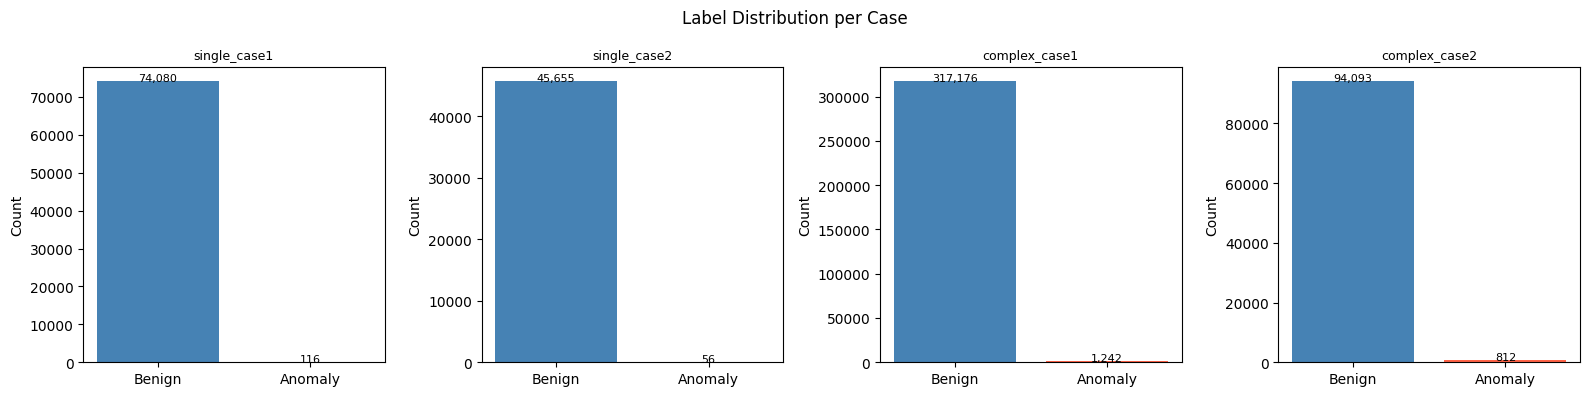

In [19]:
# ── Step 14: Label distribution bar chart ────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (name, df) in zip(axes, normalized.items()):
    counts = df['label'].value_counts().reindex([0, 1], fill_value=0)
    ax.bar(['Benign', 'Anomaly'], counts.values, color=['steelblue', 'tomato'])
    ax.set_title(name, fontsize=9)
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 50, f'{v:,}', ha='center', fontsize=8)

plt.suptitle('Label Distribution per Case', fontsize=12)
plt.tight_layout()
plt.show()

In [20]:
# ── Step 15: Sample of final preprocessed data ───────────────────────────────
FINAL_COLS = ['timestamp', 'cmdb_id'] + FEATURE_COLS + ['label', 'failure_type']

sample = normalized['single_case1'][FINAL_COLS]
print('Sample anomaly rows:')
print(sample[sample['label'] == 1].head(5).to_string(index=False))

Sample anomaly rows:
 timestamp            cmdb_id  container_cpu_usage_seconds_rate  container_cpu_system_seconds_rate  container_cpu_user_seconds_rate  container_memory_usage_bytes  container_memory_working_set_bytes  container_memory_rss  container_memory_cache  label failure_type
1719271380 observe.frontend-1                          0.000000                           0.000000                         0.000000                      0.009538                            0.008339              0.005662                0.789277      1       memory
1719271395 observe.frontend-1                          0.286414                           0.130829                         0.507246                      0.993025                            0.993321              0.993407                0.077307      1       memory
1719271410 observe.frontend-1                          0.000000                           0.000000                         0.000000                      0.993025                          

In [21]:
# ── Step 16: Save labeled CSVs to data/labeled/ ──────────────────────────────
OUTPUT_DIR = '../data/labeled'
os.makedirs(OUTPUT_DIR, exist_ok=True)

SAVE_COLS = ['timestamp', 'cmdb_id'] + FEATURE_COLS + ['label', 'failure_type']

for name, df in normalized.items():
    out_path = os.path.join(OUTPUT_DIR, f'{name}_labeled.csv')
    df[SAVE_COLS].to_csv(out_path, index=False)
    print(f'Saved: {out_path}  ({len(df):,} rows)')

print(f'\nDone. 4 files saved to {OUTPUT_DIR}/')

Saved: ../data/labeled\single_case1_labeled.csv  (74,196 rows)
Saved: ../data/labeled\single_case2_labeled.csv  (45,711 rows)
Saved: ../data/labeled\complex_case1_labeled.csv  (318,418 rows)
Saved: ../data/labeled\complex_case2_labeled.csv  (94,905 rows)

Done. 4 files saved to ../data/labeled/
